In [1]:
import os

if 'main_dir' in globals():
    os.chdir(main_dir)

import pandas as pd
from utils.load_config import load_exp_config, get_value_from_fields, get_df_historical_data
from utils.load_data import (
    get_df_from_datetime_range
    )
import numpy as np

# %matplotlib inline

if os.getcwd().endswith("notebooks"):
    main_dir = os.getcwd()
    os.chdir("..")

In [2]:
os.getuid()

1000

In [26]:
DECAY_RATE = 1

start_datetime_str = "2024-11-04 15-18-27"
end_datetime_str = "2024-11-05 08-00-00"

# end_datetime_str = start_datetime_str = "2024-11-04 14-38-04"
# end_datetime_str = start_datetime_str = "2024-10-31 13-46-21"
# end_datetime_str = start_datetime_str = "2024-11-06 11-00-44" # Error of unchanged observation
# end_datetime_str = start_datetime_str = "2024-11-06 12-08-58"

# contain large buffer and reset buffer [true, false]
start_datetime_str = "2024-11-06 12-08-58"
end_datetime_str = "2024-11-06 13-27-35"

# contain large buffer and reset buffer [true, false] with bugfix on robot pursuit
start_datetime_str = "2024-11-07 08-38-32"
end_datetime_str = "2024-11-07 10-41-32"

# end_datetime_str = start_datetime_str = "2024-11-07 11-31-51"
end_datetime_str = start_datetime_str = "2024-11-07 14-27-14"

# Full run at server
start_datetime_str = "2024-11-07 14-35-44"
end_datetime_str = "2024-11-08 04-58-17"

# Test
end_datetime_str = start_datetime_str = "2024-11-08 21-30-23"

df = get_df_from_datetime_range(start_datetime_str, 
                                end_datetime_str, 
                                decay_rate=DECAY_RATE,
                                max_iter=np.inf,
                                validity_check=False,
                                reload=False
                                )

df.head()

,time,running_objective,current_value,current_undiscounted_value,episode_id,iteration_id,task_name,step_id,phase,Linear Velocity [m/s],...,Image pixel 1193,Image pixel 1194,Image pixel 1195,Image pixel 1196,Image pixel 1197,Image pixel 1198,Image pixel 1199,absolute_path,exp_config,experiment_path
0,0.000,0.450000,None,0.450000,1,1,red,0,train,0.570429,...,0.423529,0.423529,0.423529,0.423529,0.423529,0.423529,0.423529,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...
1,0.000,0.350000,None,0.800000,1,1,red,1,train,0.359195,...,0.423529,0.423529,0.423529,0.423529,0.423529,0.423529,0.423529,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...
2,0.165,0.450000,None,1.250000,1,1,red,2,train,0.093597,...,0.423529,0.423529,0.423529,0.423529,0.423529,0.423529,0.423529,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...
3,0.330,0.650000,None,1.900000,1,1,red,3,train,0.519706,...,0.423529,0.423529,0.423529,0.423529,0.423529,0.423529,0.423529,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...
4,0.495,0.591667,None,2.491667,1,1,red,4,train,0.424844,...,0.423529,0.423529,0.423529,0.423529,0.423529,0.423529,0.423529,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...


In [27]:
exp_config = df.exp_config.values[0]
df = df.reindex()
def extract_columns(row):
    scenario = row.exp_config["scenario"]["_target_"].split(".")[-1]
    is_reset_buffer = row.exp_config["scenario"]["reset_rb_each_task"]
    buffer_size = row.exp_config["scenario"]["buffer_size"]
    learning_starts = row.exp_config["scenario"]["learning_starts"]
    controller = "SAC" if "sac" in scenario.lower() else "TD3"
    category = scenario[:scenario.find(controller)]
    return category, controller, is_reset_buffer, buffer_size, learning_starts
    
    # return pd.Series(data=[category, controller, is_reset_buffer, buffer_size], 
    #                  index=["category", "controller", "is_reset_buffer", "buffer_size"])

tmp = df.apply(extract_columns, axis=1, result_type='expand')
# tmp = df.exp_config.apply(extract_columns)
tmp.columns = ["category", "controller", "is_reset_buffer", "buffer_size", "learning_starts"]
df = pd.concat([df, tmp], axis=1)

In [28]:
df.head()

,time,running_objective,current_value,current_undiscounted_value,episode_id,iteration_id,task_name,step_id,phase,Linear Velocity [m/s],...,Image pixel 1198,Image pixel 1199,absolute_path,exp_config,experiment_path,category,controller,is_reset_buffer,buffer_size,learning_starts
0,0.000,0.450000,None,0.450000,1,1,red,0,train,0.570429,...,0.423529,0.423529,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,PushingObject,SAC,,16000,400
1,0.000,0.350000,None,0.800000,1,1,red,1,train,0.359195,...,0.423529,0.423529,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,PushingObject,SAC,,16000,400
2,0.165,0.450000,None,1.250000,1,1,red,2,train,0.093597,...,0.423529,0.423529,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,PushingObject,SAC,,16000,400
3,0.330,0.650000,None,1.900000,1,1,red,3,train,0.519706,...,0.423529,0.423529,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,PushingObject,SAC,,16000,400
4,0.495,0.591667,None,2.491667,1,1,red,4,train,0.424844,...,0.423529,0.423529,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,PushingObject,SAC,,16000,400


In [7]:
pd.Series(tmp.iloc[0], index=["category", "controller", "is_reset_buffer", "buffer_size"])

category           PushingObject
controller                   SAC
is_reset_buffer                 
buffer_size                16000
Name: 0, dtype: object

In [8]:
############################### Robot Pursuit is misisng ###############################
# group_df = df.groupby(["controller", "category", "task_name", "is_reset_buffer"]).last()
group_df = df.groupby(["controller", "category", "buffer_size"]).last()
group_df

,,,time,running_objective,current_value,current_undiscounted_value,episode_id,iteration_id,task_name,step_id,phase,Linear Velocity [m/s],...,Image pixel 1194,Image pixel 1195,Image pixel 1196,Image pixel 1197,Image pixel 1198,Image pixel 1199,absolute_path,exp_config,experiment_path,is_reset_buffer
controller,category,buffer_size,,,,,,,,,,,,,,,,,,,,,
SAC,PushingObject,16000,4.62,0.78932,None,25.574454,1,914,yellow,119,eval,0.059463,...,0.423529,0.423529,0.423529,0.423529,0.423529,0.423529,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,


In [9]:
group_df.index.names, group_df.index[0]

(FrozenList(['controller', 'category', 'buffer_size']),
 ('SAC', 'PushingObject', 16000))

In [10]:
"\t".join([f"{a}:{b}" for a, b in list(zip(group_df.index.names, group_df.index[0]))])
# list(zip(group_df.index.names, group_df.index[0]))
group_df.index

MultiIndex([('SAC', 'PushingObject', 16000)],
           names=['controller', 'category', 'buffer_size'])

In [11]:
df = df.reset_index().set_index(group_df.index.names)
tmp_df = df.loc[group_df.index[0]]

In [12]:
from matplotlib import rc
# rc('font',**{'family':'sans-serif','sans-serif':['Helvelica']})
# for Palatino and other serif fonts use:
# rc('font',**{'family':'serif','serif':['Palatino']})
rc('text', usetex=False)

In [13]:
import matplotlib
print(matplotlib.matplotlib_fname())
matplotlib.__version__

/home/tcc/huyhoang/irlc_2025/regelum-playground-iclr/venv/lib/python3.10/site-packages/matplotlib/mpl-data/matplotlibrc


'3.9.2'

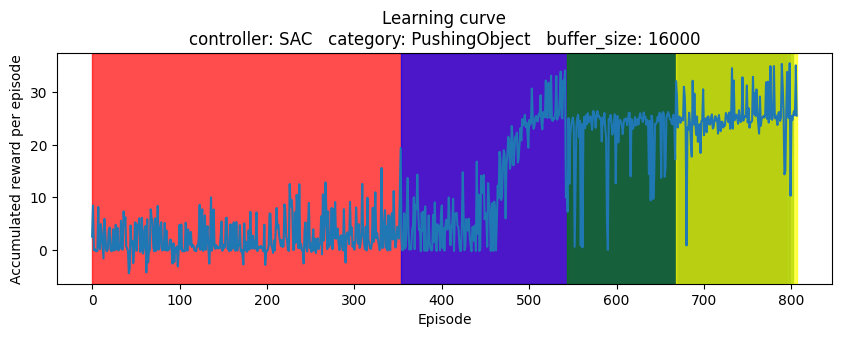

In [57]:
import matplotlib.pyplot as plt
# import matplotlib
# %matplotlib inline

def plot_learning_curve(index, index_names, df):
    fig, ax = plt.subplots(figsize=(10,3))

    df = df.reset_index().set_index(index_names)
    tmp_df = df.loc[index]

    # Filter exploration actions
    tmp_df = tmp_df.loc[:, ["iteration_id", "step_id", "task_name", "current_undiscounted_value", "learning_starts", "phase"]]
    tmp_df = tmp_df[np.invert(np.logical_and(tmp_df.phase == "train", tmp_df.step_id <= tmp_df.learning_starts))]
    tmp_group_df = tmp_df.groupby("iteration_id")

    tmp_group_df = tmp_group_df.aggregate({
        "current_undiscounted_value": "last", 
        "task_name": "last",
        "step_id": "last"
        })
    
    # Re-assign index for ploting
    tmp_group_df = tmp_group_df.reset_index()
    tmp_group_df.iteration_id = tmp_group_df.reset_index().index
    tmp_group_df = tmp_group_df.set_index("iteration_id")

    tmp_group_df.plot(y="current_undiscounted_value", ax=ax)

    colors = ["red", "blue", "green", "yellow"]
    for t in tmp_group_df.task_name.unique():
        for c in colors:
            if c in t.lower():
                break

        tmp = tmp_group_df.reset_index().set_index("task_name").loc[t]
        ax.axvspan(tmp.iteration_id.values[0], tmp.iteration_id.values[-1], alpha=0.7, color=c)

    ax.set_xlabel('Episode')
    ax.set_ylabel('Accumulated reward per episode')
    ax.set_title(
        'Learning curve\n' + 
        "   ".join([f"{a}: {b}" for a, b in list(zip(index_names, index))])
    )
    legend = ax.legend()
    legend.remove()


for id in group_df.index:
    plot_learning_curve(id, group_df.index.names, df)
# plot_learning_curve(group_df.index[1], group_df.index.names, df)
# plot_learning_curve(('SAC', 'LineFollowing', True), group_df.index.names, df)
# plot_learning_curve(('TD3', 'LineFollowing', False), group_df.index.names, df)
# plt.show()

,step_id,task_name,current_undiscounted_value,learning_starts,phase
iteration_id,,,,,
0,406,red,2.535705,400,train
1,426,red,8.447552,400,train
2,430,red,-0.050000,400,train
3,436,red,0.200000,400,train
4,441,red,-0.207692,400,train
...,...,...,...,...,...
802,114,green,25.713806,400,eval
803,29,yellow,26.454075,400,eval
804,59,yellow,25.671446,400,eval


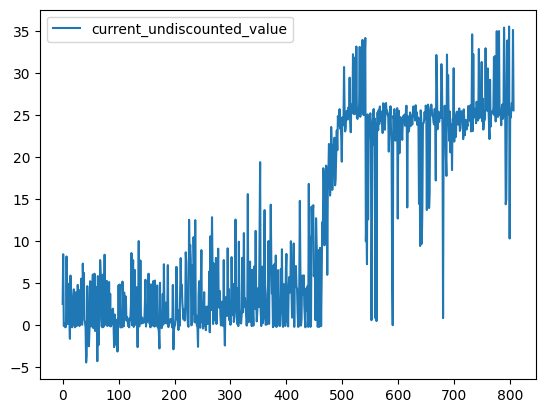

In [51]:
tmp_df = df.loc[:, ["iteration_id", "step_id", "task_name", "current_undiscounted_value", "learning_starts", "phase"]]
tmp_df = tmp_df[np.invert(np.logical_and(tmp_df.phase == "train", tmp_df.step_id <= tmp_df.learning_starts))]
g = tmp_df.groupby("iteration_id").last()
g = g.reset_index()
g.iteration_id = g.reset_index().index
g.plot(y="current_undiscounted_value")
g.set_index("iteration_id")

In [15]:
df = df.reset_index().set_index(["controller", "category", "buffer_size", "task_name"])
df[df.running_objective == 10].loc[['SAC']]

index   time  \
controller category      buffer_size task_name                 
SAC        PushingObject 16000       blue          20  3.135   
                                     blue          20  3.135   
                                     blue          17  2.640   
                                     blue          24  3.795   
                                     blue          26  4.125   
                                     blue          27  4.323   
                                     blue          27  4.290   
                                     blue          21  3.300   
                                     blue          28  4.455   
                                     blue          28  4.455   
                                     blue          20  3.135   
                                     blue          29  4.620   
                                     blue          24  3.828   
                                     blue          28  4.455   
                                     blue          22  3.465   
                                     blue          27  4.290   
                                     blue          29  4.620   
                                     blue          29  4.620   
                                     yellow        15  2.310   
                                     yellow        18  2.805   
                                     yellow        22  3.465   
                                     yellow        24  3.795   
                                     yellow        18  2.805   
                                     yellow        27  4.290   
                                     yellow        24  3.795   
                                     yellow        28  4.455   
                                     yellow        27  4.290   
                                     yellow        26  4.125   
                                     yellow        28  4.455   
                                     yellow        29  4.653   
                                     yellow        28  4.455   
                                     yellow        28  4.488   
                                     yellow        26  4.125   
                                     yellow        28  4.488   
                                     yellow        27  4.290   
                                     yellow        28  4.455   
                                     yellow        24  3.795   
                                     yellow        25  3.960   
                                     yellow        23  3.663   
                                     yellow        28  4.455   
                                     yellow        27  4.290   
                                     yellow        29  4.653   
                                     yellow        29  4.620   
                                     yellow        29  4.620   
                                     yellow        25  3.960   
                                     blue          28  4.455   
                                     blue          29  4.620   
                                     yellow        29  4.620   

                                                running_objective  \
controller category      buffer_size task_name                      
SAC        PushingObject 16000       blue                    10.0   
                                     blue                    10.0   
                                     blue                    10.0   
                                     blue                    10.0   
                                     blue                    10.0   
                                     blue                    10.0   
                                     blue                    10.0   
                                     blue                    10.0   
                                     blue                    10.0   
                                     blue                    10.0   
                   

<Axes: xlabel='iteration_id'>

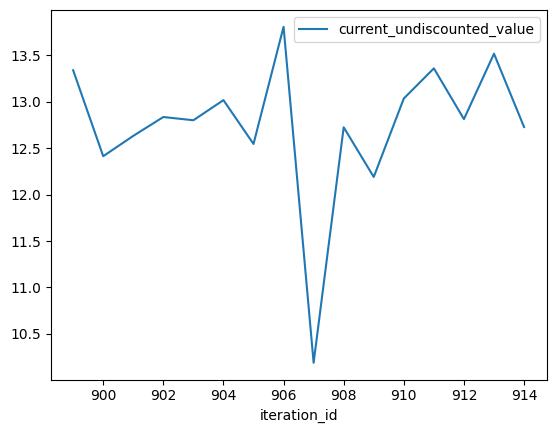

In [16]:
df = df.reset_index().set_index(["controller", "category", "buffer_size", "task_name"])
df = df.reset_index().set_index(group_df.index.names)
tmp_df = df.loc[group_df.index]

tmp_group_df = tmp_df.loc[:, ["iteration_id", "step_id", "task_name", "current_undiscounted_value", "phase"]].groupby("iteration_id")
tmp_group_df = tmp_group_df.aggregate({
    "current_undiscounted_value": "mean", 
    "task_name": "last",
    "step_id": "last",
    "phase": "last"
    })
tmp_group_df[tmp_group_df.phase=="eval"].plot(y="current_undiscounted_value")

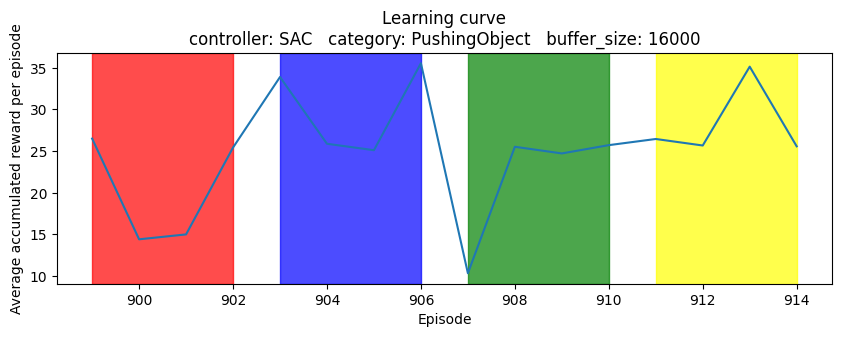

In [25]:
for id in group_df.index:
    plot_learning_curve(id, group_df.index.names, df[df.phase=="eval"])

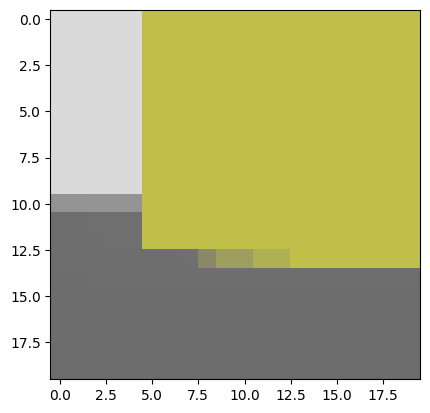

In [17]:
# df = df.reset_index()
pixel_columns = [c for c in df.columns if "pixel" in c.lower()]
chosen_state = np.array(df.loc[:, pixel_columns].iloc[-1])
im = chosen_state.reshape((20, 20, 3))

plt.imshow(im)

In [18]:
# from src.objective import RobotPursuitRunningObjective

# objective_func = RobotPursuitRunningObjective()

# objective_func(state=im, 
#                catcher_pos=[1, 1], 
#                runner_pos=[0, 0], 
#                action=[1, 0], 
#                step_count=0, 
#                max_steps_per_episode=100,
#                runner_collision_thickness=0.49,
#                arena_bounds=[-2.5,2.5,-2.5,2.5],
#                info={})

In [19]:
import numpy as np
np.sum(im)

682.4353

KeyError: ('SAC', 'LineFollowing', False)

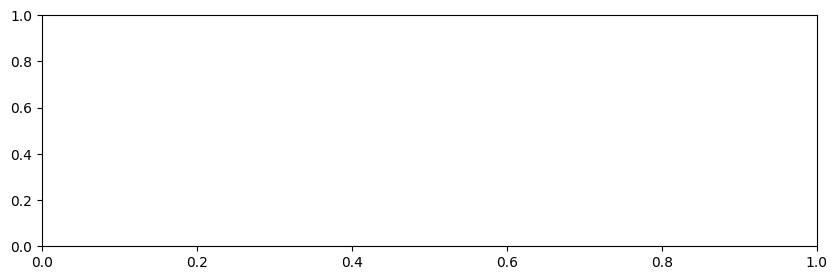

In [20]:
plot_learning_curve(('SAC', 'LineFollowing', False), group_df.index.names, df)
plot_learning_curve(('SAC', 'LineFollowing', True), group_df.index.names, df)

In [ ]:
tmp_df["previous_step"] = [tmp_df.step_id.values.tolist()[0]] + tmp_df.step_id.values.tolist()[:-1]
tmp_df[(tmp_df.step_id.diff() < 0)]
# tmp_df.step_id.values.tolist()[1:]+ [tmp_df.step_id.values.tolist()[-1]]

/tmp/ipykernel_127043/3476527340.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp_df["previous_step"] = [tmp_df.step_id.values.tolist()[0]] + tmp_df.step_id.values.tolist()[:-1]


index   time  running_objective  \
controller category      is_reset_buffer                                    
SAC        LineFollowing False                6  0.000           0.408163   
                         False                8  0.198           0.000000   
                         False                9  0.363           0.000000   
                         False               10  0.528           0.000000   
                         False               11  0.693           0.000000   
                         False                2  0.000           0.693878   
                         False               15  0.000           0.734694   
                         False               18  0.363           0.979592   
                         False               19  0.528           0.979592   
                         False               20  0.693           0.897959   
                         False               21  0.858           0.775510   
                         False               22  1.023           0.530612   
                         False               23  1.188           0.285714   
                         False               24  1.353           0.081633   
                         False               25  1.518           0.040816   
                         False               26  1.683          -1.000000   
                         False                0  0.000           0.530612   

                                         current_value  \
controller category      is_reset_buffer                 
SAC        LineFollowing False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   

                                          current_undiscounted_value  \
controller category      is_reset_buffer                               
SAC        LineFollowing False                              2.693878   
                         False                              2.857143   
                         False                              2.857143   
                         False                              2.857143   
                         False                              2.857143   
                         False                              2.122449   
                         False                              5.755102   
                         False                              8.448980   
                         False                              9.428571   
                         False                             10.326531   
                         False                             11.102041   
                         False                             11.632653   
                         False                             11.918367   
                         False                             12.000000   
                         False                             12.040816   
                         False                             11.040816   
                         False                              0.530612   

                                          episode_id  iteration_id  \
controller category      is_reset_bu

In [ ]:
tmp_df[tmp_df.iteration_id == 1196]

index   time  running_objective  \
controller category      is_reset_buffer                                    
SAC        LineFollowing False                0  0.000           0.693878   
                         False                1  0.000           0.857143   
                         False               15  0.000           0.734694   
                         False               16  0.000           0.775510   
                         False               17  0.165           0.938776   
                         False                2  0.198           0.979592   
                         False                3  0.363           0.775510   
                         False               18  0.363           0.979592   
                         False                4  0.528           0.408163   
                         False               19  0.528           0.979592   
                         False                5  0.693           0.448980   
                         False               20  0.693           0.897959   
                         False                6  0.858           0.326531   
                         False               21  0.858           0.775510   
                         False                7  1.023           0.122449   
                         False               22  1.023           0.530612   
                         False                8  1.188           0.040816   
                         False               23  1.188           0.285714   
                         False                9  1.353           0.040816   
                         False               24  1.353           0.081633   
                         False               10  1.518           0.040816   
                         False               25  1.518           0.040816   
                         False               11  1.683           0.000000   
                         False               26  1.683          -1.000000   
                         False               12  1.848           0.081633   
                         False               13  2.013           0.081633   
                         False               14  2.178           0.122449   

                                         current_value  \
controller category      is_reset_buffer                 
SAC        LineFollowing False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   

                                          current_undiscounted_value  \
controller category      is_reset_buffer             